
# **Unleashing Quantitative and Qualitative Data Analysis through Generative AI**

Welcome! We hope this workshop will be an enjoyable experience for you regardless of your experience with generative AI or with Python. Although some knowledge of each will be useful, we've tried to design this workshop so that you can jump into it without any prior experience with either.

<br>

### ☑️ **How to use this Notebook**
- Create a copy for your own records by clicking on **File > Save a copy in Drive**
- You do not need to write code. Run each cell in order: click the "Play" button (▶) on the left of a cell, or click inside the cell and press **Shift + Enter**.
- Some lines will be marked with **🔧 Try it** have a value or text you can change. Feel free to change it and run the cell again.

<br>

This notebook will walk you through a qualitative data anlysis pipeline using Python and AI. Our notebook is broken into six sections to guide you through our exercise:


1.   Initial Setup
2.   Loading Interview Data
3.  Explorative Data Analysis with Python
4. Interacting with the Model
5. Deductive Analisys
6. Inductive Analysis


During the workshop, we will use 10 de-identified, semi-structured interviews with instructors who teach undergraduates with quantitative data in the social sciences at the University of California, Santa Barbara. Our notebook is built with the following question in mind:

***How do university instructors adapt their data-teaching practices to meet diverse student needs and evolving technological and institutional contexts?***

# 1. Initial Setup
## 1.a Install Libraries and Set Environment

Run this first. It installs a few extra tools Colab doesn't ship with and loads everything we'll need. We wrote some comments in there in case youa re curios as to what each line adds to our notebook. It will take a minute or two, and you'll see a green check when it's done.


In [ ]:
!pip install pypdf --quiet
!pip install -U openai --quiet

# General tools
import os                                  # work with files and folders
import glob                                # find files by pattern, e.g. all PDFs in a folder
import json                                # read and write JSON (the format the model returns)
import textwrap                            # shorten long passages before sending to the model
import pandas as pd                        # tables and spreadsheets in Python
from getpass import getpass                # hidden input box
from google.colab import files, userdata   # Colab helpers: upload/download files, read secrets (API keys)


# Data visualization libraries
import matplotlib.pyplot as plt            # create charts
import seaborn as sns                      # nicer-looking charts built on matplotlib
from wordcloud import WordCloud            # generate word cloud images
sns.set_theme(style="whitegrid")           # set a clean default look for all charts

# Working with text data
import re                                  # regular expressions for cleaning and splitting text
from pypdf import PdfReader                # read text out of PDF files
from textblob import TextBlob              # simple sentiment scoring
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer  # count words and compute TF-IDF
from sklearn.decomposition import PCA      # reduce many dimensions to 2 for plotting
import logging                                      # control warning messages
logging.getLogger("pypdf").setLevel(logging.ERROR)  # hide harmless pdf formatting warnings

# Accesing LLM
from openai import OpenAI                           # client for sending requests to the model
from tqdm import tqdm                               # progress bars for long loops
from concurrent.futures import ThreadPoolExecutor   # run several model requests at the same time

### Setting up an output folder
OUTPUT_DIR = "outputs"                     # all csv files and charts are saved here
os.makedirs(OUTPUT_DIR, exist_ok=True)     # create it if it doesn't exist yet

## 1.b Set up your API key

This cell tells the notebook which AI service to talk to and which key to use. For today, we will use Option A with the API key provided by ASU's Create AI.

If you come back to this notebook later with your own OpenAI key, just swap which lines are commented out, as described in the cell.

In [ ]:
# OPTION A - workshop: paste the ASU CreateAI token when prompted (it stays hidden and is not saved in the notebook)
API_KEY = getpass("Paste the workshop API key and press Enter: ").strip()
BASE_URL = "https://api-main.aiml.asu.edu/v1"   # ASU CreateAI gateway
MODEL    = "defaults"                           # The CreateAI model uses GPT-6 Astra as its default model

# 🔧 Try it: OPTION B - Using your own OpenAI key: comment out the 3 lines above, uncomment the 3 lines below (save key in Colab Secrets as OPENAI_API_KEY)
# API_KEY  = userdata.get("OPENAI_API_KEY")
# BASE_URL = None                               # None = OpenAI's own endpoint
# MODEL    = "gpt6_luna"                           # any OpenAI model name

Paste the workshop API key and press Enter: ··········


## 1.c Check Connection to API

Now we open the connection and send a tiny test message to make sure everything works. Think of client as your phone line to the model; every request from here on goes through it. If you see "Connected", you're good to go. If not, the message will tell you the most likely fix, which is almost always re-pasting the key.

There are the three most common causes why your API key might not be working:
1. The key was pasted incompletely or with extra spaces - re-run the cell above and paste again"
2. The key and BASE_URL belong to different environments (prod / beta / poc)  
3. The model name is not available through the API"

In [ ]:
client = OpenAI(api_key=API_KEY, base_url=BASE_URL, max_retries=5)   # python object used to make API calls

# Quick test request to confirm the key, URL, and model all work together
try:
    client.responses.create(model=MODEL, input="Reply with the single word: ready")
    print("Connection succesful!")
except Exception as e:
    print("Could not connect. Check the three most common causes:")
    print("\nTechnical details:", e)
    raise

Connection succesful!


## 1.d Run a Test, Send a Request to the Model

This is our handshale moment with the model. Let's say hello with a simple request, we will ask the model to expalin to us how it analyses qualitative data. To speed things up. let's give it a word limit. Feel free to change the question.

In [ ]:
response = client.responses.create(
    model=MODEL,
    input=[{
        "role": "user",
        "content": [{"type": "input_text", "text": "Explain how you analyze qualitative data in 500 words or less."}] }] #🔧 Try it: Feel free to change this question
)
print(response.output_text)

Qualitative data analysis is a systematic, interpretive process for understanding how people make meaning within particular social contexts. It involves more than summarizing responses or counting repeated words: researchers develop interpretations while examining how their own perspectives and relationships shape those interpretations.

My approach depends on the research question, theoretical orientation, and type of data. A typical process includes the following steps.

### 1. Clarify the analytic purpose
I establish what the analysis seeks to understand and what assumptions guide it. A **constructivist approach** examines how meanings are produced through experience and interaction; a **critical approach** also examines how power, institutions, and structural inequalities shape those meanings. These orientations influence what I notice and how I interpret it.

### 2. Prepare and contextualize the material
I organize transcripts, field notes, documents, or other materials; check the

# 2. Load Interview Data

## 2.a Find the Files
Time for data. For this exercie, we'll pull ten interview transcripts from the workshop repository.

If you'd rather use your own transcripts, uncomment the two lines at the bottom and you'll get an upload button.


In [ ]:
# Workshop files: use the 10 interviews available in the workshop's GitHub repository
if not os.path.exists("llms-for-qual"):
    !git clone -q https://github.com/namigabbasov/llms-for-qual.git
paths = sorted(glob.glob("llms-for-qual/data/*.pdf"))

# 🔧 Try it: When using this notebook for your own data uncomment the 2 lines  below to upload your own PDF or TXT transcripts
# uploaded = files.upload()
# paths = sorted(uploaded.keys())

print(f"Found {len(paths)} interview files")

Found 10 interview files


## 2.b Read and clean text
This cell opens each file, pulls out the text, and tidies up stray line breaks and spacing so the model gets clean prose to work with.


In [ ]:
# Read and clean text of each interview
docs = {}
for path in paths:
    name = os.path.splitext(os.path.basename(path))[0]
    if path.lower().endswith(".pdf"):
        reader = PdfReader(path)
        text = " ".join(p.extract_text() or "" for p in reader.pages)
    else:
        with open(path, "r", encoding="utf-8") as f:
            text = f.read()
    docs[name] = re.sub(r"\s+", " ", text).strip()

print(f"Loaded {len(docs)} documents:")
for d in docs:
    print(" •", d)

Loaded 10 documents:
 • UCSB01
 • UCSB02
 • UCSB03
 • UCSB04
 • UCSB05
 • UCSB06
 • UCSB07
 • UCSB08
 • UCSB09
 • UCSB10


# 3. Exploratory Data Analysis with Python

## 3.a Document stats
To start our exploraiton, let's build a small table of basic facts per interview: how many words, how many characters, average word length.

Think for a second, from a qualitative analysis point of view, what might this tyoe of data tell us?


In [ ]:
# Check each interview file for word count, character lenght, and average word lenght
df = pd.DataFrame(list(docs.items()), columns=["File name", "text"])
df["Word count"] = df["text"].apply(lambda x: len(x.split()))
df["Char count"] = df["text"].apply(len)
df["Avg word length"] = df["text"].apply(lambda x: sum(len(w) for w in x.split()) / max(len(x.split()), 1))

# Printing the table
print("Basic stats per document:")
display(df[["File name", "Word count", "Char count", "Avg word length"]])
df[["File name", "Word count", "Char count", "Avg word length"]].to_csv(f"{OUTPUT_DIR}/document_stats.csv", index=False)

Basic stats per document:


,File name,Word count,Char count,Avg word length
0,UCSB01,6649,36405,4.475410
1,UCSB02,5442,29759,4.468578
2,UCSB03,5937,32384,4.454775
3,UCSB04,7962,43388,4.449510
4,UCSB05,5697,31033,4.447428
5,UCSB06,7826,43074,4.504089
6,UCSB07,8191,44895,4.481138
7,UCSB08,5412,29731,4.493718
8,UCSB09,9430,52435,4.560551
9,UCSB10,4178,22863,4.472475


## 3.b Document lengths
We can take the information from ***3.a*** and create some visualizations
The code below creates a bar chart with the DataFrame we built in the last code cell.

Are some interviews much longer than others? How could this affect how themes appear in the data?


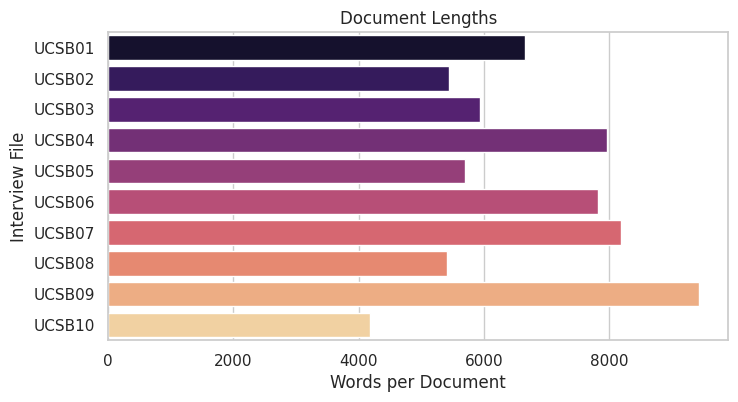

In [ ]:
# Create a simple bar plot using the DataFrame we just built
plt.figure(figsize=(8,4))
sns.barplot(y="File name", x="Word count", data=df, hue="File name", palette="magma", legend=False)
plt.title("Document Lengths")
plt.xlabel("Words per Document"); plt.ylabel("Interview File")
plt.savefig(f"{OUTPUT_DIR}/document_lengths.png", dpi=150, bbox_inches="tight")
plt.show()

## 3.c Word cloud
A classic. Word clouds are not rigorous analysis, but they're a fast, visual gut check on what people talked about most.


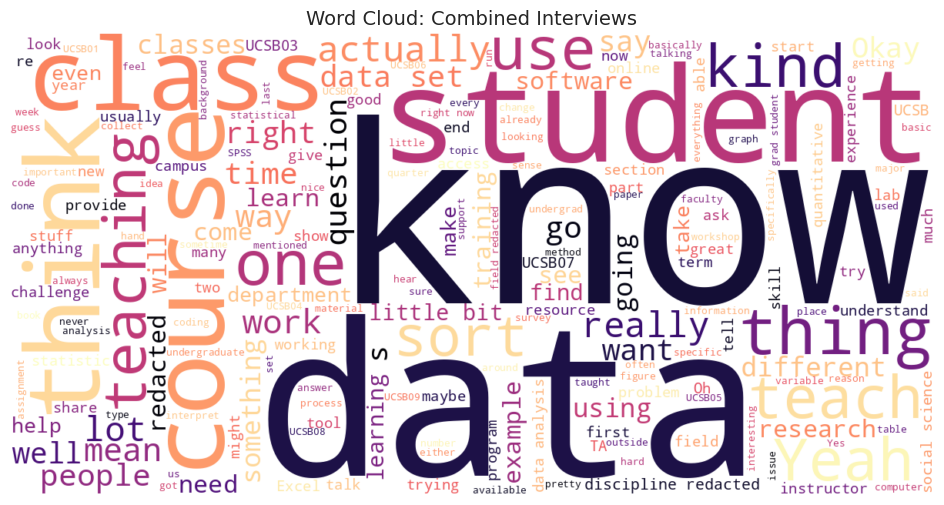

In [ ]:
# Create a corpus using our texts
corpus = " ".join(df["text"])

# Set up the wordcloud
wc = WordCloud(width=1200, height=600, background_color="white", colormap="magma").generate(corpus)

# Print a figure that shows the wordcloud
plt.figure(figsize=(12,6))
plt.imshow(wc, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud: Combined Interviews", fontsize=14)
plt.savefig(f"{OUTPUT_DIR}/word_cloud.png", dpi=150, bbox_inches="tight")
plt.show()

## 3.d Top 20 words
A more precise version of the word cloud: the twenty most frequent words across all interviews, with common filler words like "the" and "and" removed.


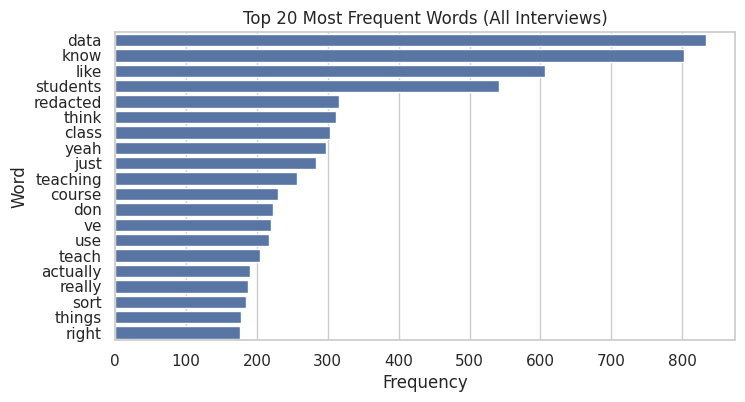

In [ ]:
# Count how often each word appears across all interviews
# stop_words="english" drops filler words like "the", "and", "is"; max_features keeps the 1000 most common
vectorizer = CountVectorizer(stop_words="english", max_features=1000)
X = vectorizer.fit_transform(df["text"])   # X is a table: one row per interview, one column per word

# Turn the counts into a tidy two-column table (word, count), biggest first
word_freq = pd.DataFrame({
    "word": vectorizer.get_feature_names_out(),   # the words
    "count": X.toarray().sum(axis=0)              # total count of each word across all interviews
}).sort_values("count", ascending=False)

# Plot the top 20 as a horizontal bar chart and save it to the outputs folder
plt.figure(figsize=(8,4))
sns.barplot(y="word", x="count", data=word_freq.head(20))
plt.title("Top 20 Most Frequent Words (All Interviews)")
plt.xlabel("Frequency"); plt.ylabel("Word")
plt.savefig(f"{OUTPUT_DIR}/top_words.png", dpi=150, bbox_inches="tight")
plt.show()

## 3.e Finding distinctive words

Here we will use Term Frequency-Inverse Document Frequency (TF-IDF) to find the most disticntive words in our dataset. TF-IDF is a statistical score that measures how important a word is to a document in a corpus.

Frequent words aren't always interesting words. TF-IDF highlights terms that are distinctive, meaning they show up a lot in some interviews but not everywhere.

Run the cell below and look at the top words, what do you think this can tell us about the data?


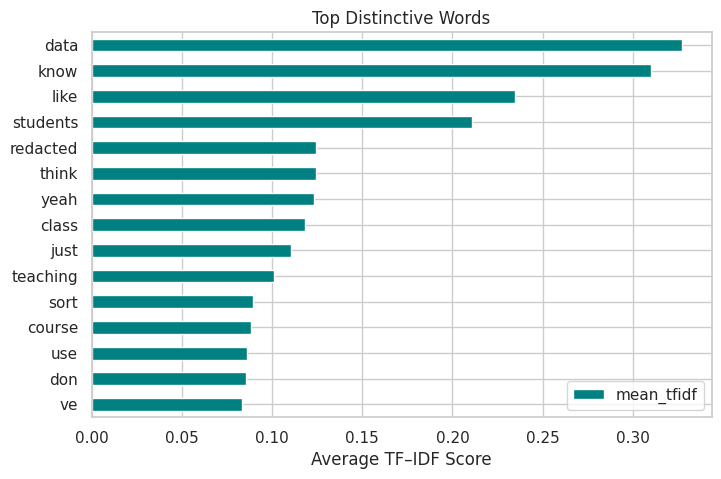

In [ ]:
# Score each word by how distinctive it is, not just how frequent
# TF-IDF rewards words that appear a lot in some interviews but not in all of them
tfidf = TfidfVectorizer(stop_words="english", max_features=1500) # Keep only the 1500 most common words in each interview
X_tfidf = tfidf.fit_transform(df["text"])

# Put the scores in a table: one row per interview, one column per word
tfidf_df = pd.DataFrame(X_tfidf.toarray(), columns=tfidf.get_feature_names_out(), index=df["File name"])

# Average each word's score across interviews and keep the top 15
top_terms = pd.DataFrame(tfidf_df.mean().sort_values(ascending=False).head(15))
top_terms.columns = ["mean_tfidf"]

# Plot as a horizontal bar chart (invert_yaxis puts the highest score at the top) and save it
top_terms.plot(kind="barh", figsize=(8,5), color="teal")
plt.gca().invert_yaxis()
plt.title("Top Distinctive Words")
plt.xlabel("Average TF–IDF Score")
plt.savefig(f"{OUTPUT_DIR}/top_tfidf_words.png", dpi=150, bbox_inches="tight")
plt.show()

## 3.f PCA word-use
We wil use Principal Component Analysis to follow up our TF-IDF. Each interview is currently described by hundreds of word scores. PCA boils those down to two summary scores per interview, each a blend of words that tend to appear together, so we can plot the interviews on a map.

The plot below shows each interview on a 2D map, where interviews using similar vocabulary land close together. One caveat: the axes themselves don't mean anything you can name, and "similar words" is not the same as "similar ideas." Treat this as a hint about groupings.


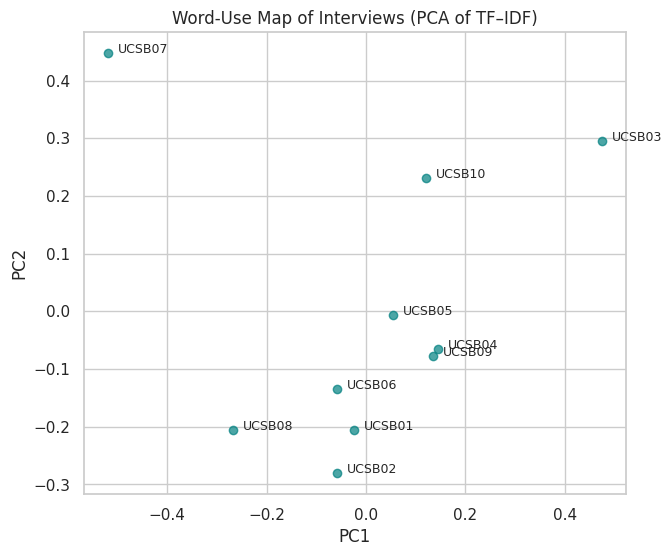

In [ ]:
# Each interview is currently described by 1500 numbers (one TF-IDF score per word)
# PCA squeezes those down to just 2 numbers so we can plot interviews on a flat map
pca = PCA(n_components=2)
coords = pca.fit_transform(X_tfidf.toarray())   # one (x, y) pair per interview

# Draw one dot per interview, labeled with its file name
plt.figure(figsize=(7,6))
plt.scatter(coords[:,0], coords[:,1], alpha=0.7, color="teal")
for i, fn in enumerate(df["File name"]):
    plt.text(coords[i,0]+0.02, coords[i,1], fn.split('.')[0], fontsize=9)   # label next to each dot

# Interviews that use similar words land close together; the axes themselves have no simple meaning
plt.title("Word-Use Map of Interviews (PCA of TF–IDF)")   # similarity in vocabulary, not true meaning
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.savefig(f"{OUTPUT_DIR}/interview_map_pca.png", dpi=150, bbox_inches="tight")
plt.show()

# 4. Interacting with the Model


## 4.a Prompt the Model to Summarize the Data
Here's our first real task for the model: we hand all ten transcripts to the model and ask for a summary. The text we extracted in the previous cell is sent directly to the model. Feel free to change the question. This is a nice way to get a quick lay of the land before diving into structured analysis, and a good sanity check.


In [ ]:
# Combine all interviews into one text, each labeled with its File name
corpus = "\n\n".join(f"[{name}] {text}" for name, text in docs.items())

# Ask the model about the interviews - feel free to change question below
content = [{"type": "input_text", "text": f"Summarize the main ideas raised across these interviews in 500 words or less.\n\n{corpus}"}] #🔧 Try it: Feel free to modify this quesiton

response = client.responses.create(
    model=MODEL,
    input=[{"role": "user", "content": content}]
)
print(response.output_text)

## Main ideas across the interviews

Across these ten instructors’ accounts, teaching with data involves balancing technical skills, interpretation, student confidence, and institutional constraints. Although approaches differ, several recurring themes emerge.

**1. Understanding matters more than operating software.**  
Instructors emphasize interpreting findings, connecting analyses to research questions, and communicating results rather than merely calculating statistics or following commands. Critical data literacy includes recognizing misleading graphs, distinguishing correlation from causation, questioning how measures are constructed, and assessing what samples represent. These skills are presented as valuable for research, employment, and everyday information use.

**2. Data selection balances authenticity and manageability.**  
Most instructors provide curated datasets or direct students to established repositories, often simplifying data to fit introductory learning goals. So


## 4.b Identifying Topics
For each interview, we will ask the model to extract three to five topic keywords. Compare these to the word-frequency charts from the previous section and notice how differently a language model "reads" a transcript.


In [ ]:
# Ask the model to label each interview with a few topic keywords, one interview at a time
topics = []
for text in tqdm(df["text"], desc="Generating topic summaries"):   # tqdm shows a progress bar as the loop runs
    prompt = f"List 3-5 concise topic keywords describing main ideas in this interview:\n\n{text}"   # #🔧 Try it: Try specifying more or less words here
    resp = client.responses.create(
        model=MODEL,
        input=[{"role": "user", "content": [{"type": "input_text", "text": prompt}]}]
    )
    topics.append(resp.output_text.strip())   # keep the model's answer, minus stray whitespace

# Add the labels as a new column, show the result, and save it to the outputs folder
df["gpt_topics"] = topics
print("GPT Topic Labels Added")
display(df[["File name", "gpt_topics"]])
df[["File name", "gpt_topics"]].to_csv(f"{OUTPUT_DIR}/gpt_topics.csv", index=False)

Generating topic summaries: 100%|██████████| 10/10 [00:40<00:00,  4.02s/it]

GPT Topic Labels Added


,File name,gpt_topics
0,UCSB01,- Critical data literacy and visualization\n- ...
1,UCSB02,- Integrated GIS software and data instruction...
2,UCSB03,- Data wrangling and R instruction\n- Digital ...
3,UCSB04,- Hands-on data collection and analysis\n- Pro...
4,UCSB05,- Social science data literacy\n- Big data eth...
5,UCSB06,- Statistical literacy and conceptual understa...
6,UCSB07,- Undergraduate data literacy\n- Survey design...
7,UCSB08,- Statistical literacy and critical interpreta...
8,UCSB09,- Critical quantitative literacy\n- Scaffolded...
9,UCSB10,- Hands-on quantitative data analysis\n- Surve...


# 5. Deductive Thematic Analysis

## 5.a Define themes and split into turns
In deductive coding, we start with themes we already have in mind, usually drawn from theory or prior work. This cell lists ours, then splits each transcript into individual instructor responses so we can code at the level of what one person said in one turn. Edit the theme list if you'd like to try your own.


In [ ]:
# Define themes
codes = [
    "Student-Centered Adjustments",
    "Tool and Technology Shifts",
    "Curriculum and Pedagogical Redesign",
    "Professional Learning and Skill Growth",
    "Collaborative and Institutional Support",
    "Relevance and Engagement Strategies"
]

# Split each interview on speaker labels - I = interviewer, UCSB01, UCSB02 ... = instructor
turn_rows = []
for name, text in docs.items():
    parts = re.split(r"(\bI\s*:|\b(?i:UCSB)\s*\d*\s*:)", text)
    speakers, turns = parts[1::2], parts[2::2]

    # keep only instructor responses
    kept = [t.strip() for s, t in zip(speakers, turns) if s.upper().startswith("UCSB") and len(t.strip()) > 80]
    for j, t in enumerate(kept):
        turn_rows.append({"interview": name, "chunk_id": j + 1, "text": t})
    print(f"{name}: split into {len(turns)} turns, keeping {len(kept)} instructor responses")

turns_df = pd.DataFrame(turn_rows)
print(f"\n{len(turns_df)} instructor responses across {turns_df['interview'].nunique()} interviews")

# Preview few chunks
for _, r in turns_df.head(3).iterrows():
    print(f"\n--- {r['interview']} RESPONSE {r['chunk_id']} ---\n{r['text'][:250]}...\n")

UCSB01: split into 61 turns, keeping 26 instructor responses
UCSB02: split into 56 turns, keeping 22 instructor responses
UCSB03: split into 113 turns, keeping 43 instructor responses
UCSB04: split into 113 turns, keeping 48 instructor responses
UCSB05: split into 83 turns, keeping 36 instructor responses
UCSB06: split into 79 turns, keeping 31 instructor responses
UCSB07: split into 115 turns, keeping 41 instructor responses
UCSB08: split into 56 turns, keeping 21 instructor responses
UCSB09: split into 69 turns, keeping 30 instructor responses
UCSB10: split into 69 turns, keeping 25 instructor responses

323 instructor responses across 10 interviews

--- UCSB01 RESPONSE 1 ---
Okay, well, I teach data analysis and [discipline redacted] for undergrads. I also teach it for graduate students, and I cross list them often. And so, grad students and undergrads are in there together. In general, well, I consider it one of the mos...


--- UCSB01 RESPONSE 2 ---
Yeah, I teach it that way, ever

## 5.b Deductive Thematic Analysis
 For every instructor response, the model reads the passage and reports which themes are present (1) or absent (0). We send several requests at once to save time, so it should finish in a minute or two. Watch the progress bar.


In [ ]:
# Coding function for one response
def code_deductive(r):
    prompt = f"""
    You are a qualitative coding assistant. Read the passage and decide whether each of {len(codes)} themes appears.
    Return ONLY valid JSON with each key = theme and value = 1 (present) or 0 (absent).
    Themes: {', '.join(codes)}
    Passage: \"\"\"{textwrap.shorten(r['text'], width=6000)}\"\"\"
    """
    resp = client.responses.create(
        model=MODEL,
        input=[{"role": "user", "content": [{"type": "input_text", "text": prompt}]}],
        text={"format": {"type": "json_object"}}  ### forces JSON output
    )
    raw = resp.output_text.strip()
    try:
        result = json.loads(raw)
    except Exception:
        try:
            start, end = raw.index("{"), raw.rindex("}") + 1
            result = json.loads(raw[start:end])
        except Exception:
            result = {c: None for c in codes}
    result["interview"] = r["interview"]
    result["chunk_id"] = r["chunk_id"]
    result["chunk_preview"] = r["text"][:220] + "..."
    return result

# Run coding loop - 8 requests at a time to save time
records = turns_df.to_dict("records")
with ThreadPoolExecutor(max_workers=8) as pool:
    rows = list(tqdm(pool.map(code_deductive, records), total=len(records), desc="Coding instructor responses"))

Coding instructor responses: 100%|██████████| 323/323 [03:44<00:00,  1.44it/s]


## 5.c Results of Deductive Thematic Analysis
The coding results arrive as a tidy table: one row per response, one column per theme. We save it as a CSV, add up theme counts per interview, and chart the totals. This is the kind of output you can take straight into your own analysis


saved coding matrix as deductive_coding_matrix.csv

Preview:


,interview,chunk_id,Student-Centered Adjustments,Tool and Technology Shifts,Curriculum and Pedagogical Redesign,Professional Learning and Skill Growth,Collaborative and Institutional Support,Relevance and Engagement Strategies,chunk_preview
0,UCSB01,1,1,0,1,0,0,1,"Okay, well, I teach data analysis and [discipl..."
1,UCSB01,2,1,0,1,0,0,0,"Yeah, I teach it that way, every other year, b..."
2,UCSB01,3,1,0,1,0,0,1,"I have all of the data that they get. So, ther..."
3,UCSB01,4,0,1,0,0,0,0,I upload everything to our UCSB platform Gauch...
4,UCSB01,5,0,0,0,1,0,1,I have been working with the same datasets for...


,Student-Centered Adjustments,Tool and Technology Shifts,Curriculum and Pedagogical Redesign,Professional Learning and Skill Growth,Collaborative and Institutional Support,Relevance and Engagement Strategies
interview,,,,,,
UCSB01,14,9,13,8,9,17
UCSB02,11,3,15,5,6,11
UCSB03,12,21,14,5,16,15
UCSB04,16,11,26,4,6,26
UCSB05,13,9,14,4,9,11
UCSB06,11,7,8,8,14,13
UCSB07,21,11,28,7,13,22
UCSB08,10,7,12,4,9,13
UCSB09,17,13,17,5,17,16


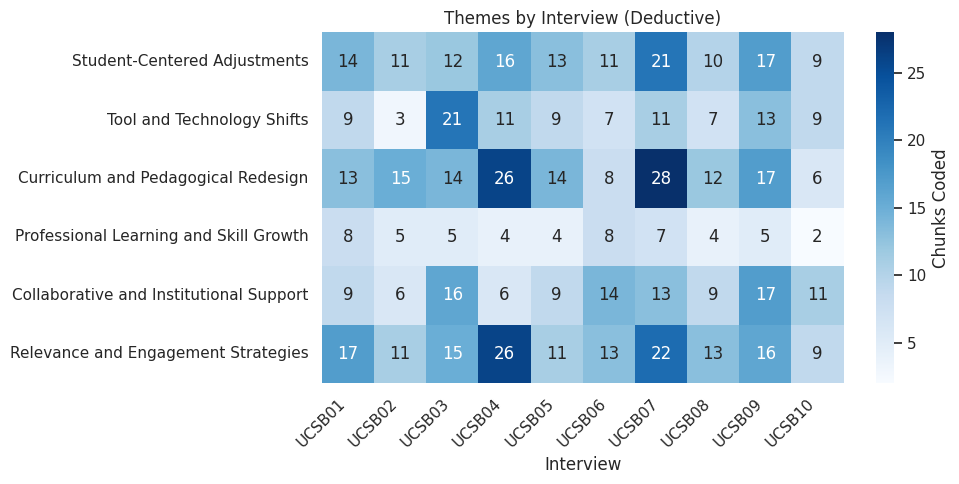


Theme counts:
 Relevance and Engagement Strategies        153
Curriculum and Pedagogical Redesign        153
Student-Centered Adjustments               134
Collaborative and Institutional Support    110
Tool and Technology Shifts                 100
Professional Learning and Skill Growth      52
dtype: int64


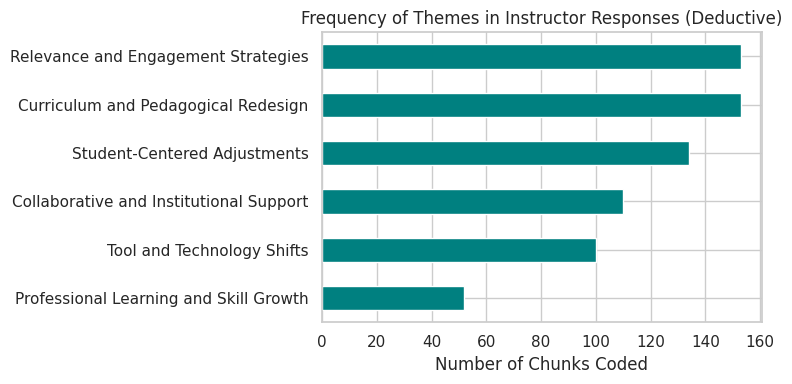

In [ ]:
# Create DataFrame, save, and preview
deductive_df = pd.DataFrame(rows)
deductive_df = deductive_df.reindex(columns=["interview", "chunk_id"] + codes + ["chunk_preview"])
deductive_df[codes] = deductive_df[codes].apply(pd.to_numeric, errors="coerce")
deductive_df.to_csv(f"{OUTPUT_DIR}/deductive_coding_matrix.csv", index=False)
print("saved coding matrix as deductive_coding_matrix.csv")
print("\nPreview:")
display(deductive_df.head())

# Theme counts per interview
deductive_by_interview = deductive_df.groupby("interview")[codes].sum().astype(int)
deductive_by_interview.to_csv(f"{OUTPUT_DIR}/deductive_themes_by_interview.csv")
display(deductive_by_interview)

# Heatmap of themes by interview
plt.figure(figsize=(10,5))
sns.heatmap(deductive_by_interview.T, annot=True, fmt="d", cmap="Blues", cbar_kws={"label": "Chunks Coded"})
plt.title("Themes by Interview (Deductive)")
plt.xlabel("Interview"); plt.ylabel("")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/deductive_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

# Summary counts and bar chart
theme_counts = deductive_df[codes].sum().sort_values(ascending=False)
print("\nTheme counts:\n", theme_counts)

# Total code counts bar chart
plt.figure(figsize=(8,4))
theme_counts.plot(kind="barh", color="teal")
plt.gca().invert_yaxis()
plt.title("Frequency of Themes in Instructor Responses (Deductive)")
plt.xlabel("Number of Chunks Coded")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/deductive_theme_counts.png", dpi=150, bbox_inches="tight")
plt.show()


# 6. Inductive Thematic Analysis
## 6.a Discovering themes
Inductive coding flips the order: instead of bringing themes to the data, we let the themes emerge from it. Here we hand the model all the transcripts and ask it to propose five or six recurring themes. Have a look at what it comes up with before moving on.

In [ ]:
# First pass: derive candidate themes from all transcripts
corpus = "\n\n".join(f"[{name}] {text}" for name, text in docs.items())
overview_prompt = f"""
Read following transcripts and list 5-6 inductive themes that best capture recurring ideas across interviews.
Give each theme a short label of 2-6 words.
Return ONLY valid JSON in this format:
{{"themes":["theme1","theme2","theme3",...]}}
Transcripts:
\"\"\"{corpus}\"\"\"
"""

resp = client.responses.create(
    model=MODEL,
    input=[{"role":"user","content":[{"type":"input_text","text":overview_prompt}]}],
    text={"format": {"type": "json_object"}}  ### forces JSON output
)

raw = resp.output_text.strip()
try:
    raw = re.sub(r"```(?:json)?", "", raw)
    raw = re.sub(r"```", "", raw)
    start, end = raw.find("{"), raw.rfind("}") + 1
    json_text = raw[start:end]
    theme_data = json.loads(json_text)
    themes = [t.strip() for t in theme_data.get("themes", [])]
except Exception:
    print("could not parse themes automatically. check output below:")
    print(raw)
    themes = []

print(f"derived {len(themes)} emergent themes:\n", themes)
with open(f"{OUTPUT_DIR}/inductive_themes.json", "w") as f:
    json.dump({"themes": themes}, f, indent=2)

derived 6 emergent themes:
 ['Scaffolding confidence amid uneven preparation', 'Interpretation beyond calculations and procedures', 'Balancing software and conceptual learning', 'Making data relevant through practice', 'Resource constraints shape teaching possibilities', 'Learning through peers and ongoing training']


## 6.b Thematic analysis with inductive themes

Now we repeat the coding step, this time using the themes the model just discovered. Same mechanics as before, different lens. Feel free to tweak the prompt if you want the model to be stricter or more generous.

In [ ]:
# Second pass: code each chunk - 0/1 per theme - feel free to change this prompt below
def code_inductive(r):
    prompt = f"""
    Determine whether each of the following themes appears in this passage.
    Return ONLY valid JSON with each theme as key and 1 (present) or 0 (absent) as value.

    Themes: {', '.join(themes)}

    Passage:
    \"\"\"{textwrap.shorten(r['text'], width=6000)}\"\"\"
    """
    resp = client.responses.create(
        model=MODEL,
        input=[{"role":"user","content":[{"type":"input_text","text":prompt}]}],
        text={"format": {"type": "json_object"}}  ### forces JSON output
    )

    raw = resp.output_text.strip()
    try:
        raw = re.sub(r"```(?:json)?", "", raw)
        raw = re.sub(r"```", "", raw)
        start, end = raw.find("{"), raw.rfind("}") + 1
        json_text = raw[start:end]
        result = json.loads(json_text)
    except Exception:
        result = {t: None for t in themes}

    result["interview"] = r["interview"]
    result["chunk_id"] = r["chunk_id"]
    result["chunk_preview"] = r["text"][:220] + "..."
    return result

# Run coding loop - 8 requests at a time to save time
records = turns_df.to_dict("records")
with ThreadPoolExecutor(max_workers=8) as pool:
    rows = list(tqdm(pool.map(code_inductive, records), total=len(records), desc="coding chunks inductively"))

coding chunks inductively: 100%|██████████| 323/323 [03:38<00:00,  1.48it/s]


## 6.c Results of Inductive Thematic Analysis

As we did before with our Deductive coding, we visualize our results with a coding matrix, per-interview counts, and two charts. The interesting bit about this part of the process is that the LLM pulled the themes out of the text without us inputing a codebook. It's worth placing this next to the deductive results and asking: how do these set of themes tells vary, and what can that tell us about our data?

Saved inductive coding matrix as inductive_coding_matrix.csv


,interview,chunk_id,Scaffolding confidence amid uneven preparation,Interpretation beyond calculations and procedures,Balancing software and conceptual learning,Making data relevant through practice,Resource constraints shape teaching possibilities,Learning through peers and ongoing training,chunk_preview
0,UCSB01,1,0,1,0,1,1,0,"Okay, well, I teach data analysis and [discipl..."
1,UCSB01,2,0,1,0,0,1,0,"Yeah, I teach it that way, every other year, b..."
2,UCSB01,3,1,1,0,1,0,0,"I have all of the data that they get. So, ther..."
3,UCSB01,4,0,0,0,0,0,0,I upload everything to our UCSB platform Gauch...
4,UCSB01,5,0,1,0,1,0,0,I have been working with the same datasets for...


,Scaffolding confidence amid uneven preparation,Interpretation beyond calculations and procedures,Balancing software and conceptual learning,Making data relevant through practice,Resource constraints shape teaching possibilities,Learning through peers and ongoing training
interview,,,,,,
UCSB01,7,12,2,12,8,8
UCSB02,5,4,5,10,6,4
UCSB03,6,6,6,7,16,5
UCSB04,6,14,4,18,13,6
UCSB05,5,3,7,9,11,8
UCSB06,7,7,3,9,7,6
UCSB07,11,13,6,20,6,7
UCSB08,6,7,6,11,5,4
UCSB09,9,15,5,13,19,5


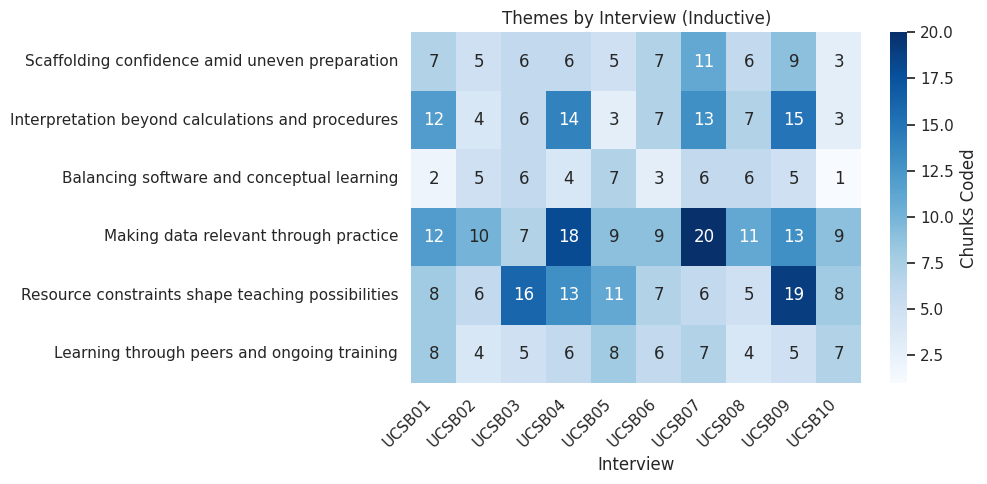


Total theme counts:
 Making data relevant through practice                118
Resource constraints shape teaching possibilities     99
Interpretation beyond calculations and procedures     84
Scaffolding confidence amid uneven preparation        65
Learning through peers and ongoing training           60
Balancing software and conceptual learning            45
dtype: int64


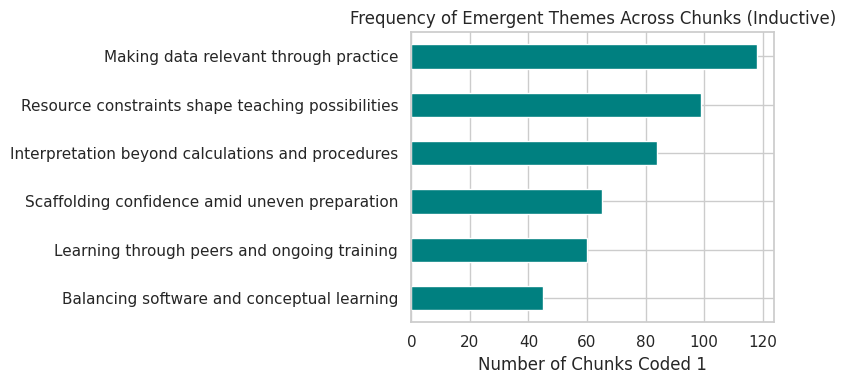

In [ ]:
# Create DataFrame, save, and preview
inductive_df = pd.DataFrame(rows)
ordered_cols = ["interview", "chunk_id"] + themes + ["chunk_preview"]
inductive_df = inductive_df.reindex(columns=ordered_cols)
inductive_df[themes] = inductive_df[themes].apply(pd.to_numeric, errors="coerce")
inductive_df.to_csv(f"{OUTPUT_DIR}/inductive_coding_matrix.csv", index=False)
print("Saved inductive coding matrix as inductive_coding_matrix.csv")
display(inductive_df.head())

# Theme counts per interview
inductive_by_interview = inductive_df.groupby("interview")[themes].sum().astype(int)
inductive_by_interview.to_csv(f"{OUTPUT_DIR}/inductive_themes_by_interview.csv")
display(inductive_by_interview)

# Heatmap of themes by interview
plt.figure(figsize=(10,5))
sns.heatmap(inductive_by_interview.T, annot=True, fmt="d", cmap="Blues", cbar_kws={"label": "Chunks Coded"})
plt.title("Themes by Interview (Inductive)")
plt.xlabel("Interview"); plt.ylabel("")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/inductive_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

# Total code counts
theme_counts = inductive_df[themes].sum().sort_values(ascending=False)
print("\nTotal theme counts:\n", theme_counts)

# Total code counts bar chart
plt.figure(figsize=(8,4))
theme_counts.plot(kind="barh", color="teal")
plt.gca().invert_yaxis()
plt.title("Frequency of Emergent Themes Across Chunks (Inductive)")
plt.xlabel("Number of Chunks Coded 1")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/inductive_theme_counts.png", dpi=150, bbox_inches="tight")
plt.show()

# Download Results
### **CONGRATULATIONS!**
You have made it through the exercises and hopefully have a better understanding of how using a generative AI to assist in your qualitative abalysis can help you do a thorough preliminary anbalysis of your interview data.

Everything we did today, including CSV files and charts, has been saved to an outputs folder. This cell zips it up and downloads it to your computer so you can go through it and see the kind of results you can obtain through this method.


In [ ]:
# Zip the outputs folder and download
!zip -rq outputs.zip outputs
files.download("outputs.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>